# 01 · Análisis exploratorio — Premier League 2000/01 a 2026/27

**Objetivo.** Entender los datos antes de modelar: calidad, cobertura, fugas de información posibles y qué tan viable
es cada feature planificada. Todo lo que se afirma acá sale de una celda de este notebook o de una fuente citada.

**Fuentes**

| Dato | Fuente | Uso |
|---|---|---|
| Resultados, estadísticas y cuotas | [Football-Data.co.uk](https://www.football-data.co.uk/) (CSV por división y temporada; columnas en [notes.txt](https://www.football-data.co.uk/notes.txt)) | Base del proyecto |
| Championship (E1) | Football-Data.co.uk | Solo para dar historial de Elo a los ascendidos |
| Elo de ClubElo | Tabla `EloRatings.csv` del dataset [Club Football Match Data](https://github.com/xgabora/Club-Football-Match-Data) (A. Gábor), snapshots los días 1 y 15 | Elo de comparación |

> **Por qué no usamos el dataset de Gábor como base** (decisión tomada tras la auditoría de la sección 3):
> le faltan 90 partidos de Premier, su columna `OddHome` mezcla casas de apuestas distintas según la temporada
> aunque el README la describe como Bet365, y su Elo posterior a junio de 2025 es una continuación
> provisional (la API pública de ClubElo dejó de funcionar: [soccerdata#977](https://github.com/probberechts/soccerdata/issues/977)).

El dataset procesado se genera con `python -m src.data.download` y `python -m src.data.load`.

In [1]:
import sys
sys.path.insert(0, '..')  # raíz del proyecto, para importar src

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src import eras, viz
from src.config import CLUBELO_SNAPSHOTS_PATH, PROCESSED_DIR, RAW_DIR
from src.data.load import load_matches
from src.metrics import OUTCOMES, reliability_table, summarize
from src.odds import booksum, proportional_probabilities, shin_probabilities

viz.use_style()
pd.set_option("display.max_columns", 60, "display.width", 160, "display.float_format", "{:.3f}".format)
FIG_DIR = Path("../reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(42)

all_matches = load_matches()
pl = all_matches[all_matches.division == "E0"].reset_index(drop=True)
quality = json.loads((PROCESSED_DIR / "data_quality.json").read_text(encoding="utf-8"))
print(f"Premier League: {len(pl):,} partidos | {pl.date.min():%d/%m/%Y} a {pl.date.max():%d/%m/%Y}")
print(f"Championship (solo para Elo propio): {(all_matches.division == 'E1').sum():,} partidos")

Premier League: 9,930 partidos | 19/08/2000 a 20/09/2026
Championship (solo para Elo propio): 14,447 partidos


## 1 · Estructura general

Un partido por fila. Las columnas se dividen en tres grupos según **cuándo se conocen**, que es lo que define si
pueden ser feature de entrada:

* **Antes del partido (usables como feature):** equipos, fecha, hora, cuotas pre-cierre, Elo vigente.
* **Al cierre del mercado (justo antes del inicio):** cuotas de cierre (`b365c_*`, `psc_*`). Son pre-partido pero se
  conocen minutos antes del inicio; se usan como **benchmark**, no como feature.
* **Después del partido (nunca como feature del mismo partido):** goles, entretiempo, tiros, faltas, córners,
  tarjetas. Se conservan porque son el target y porque **sus valores de partidos anteriores** sí son información
  legítima (p. ej., goles promedio de las últimas fechas), siempre calculados con datos estrictamente previos.

In [2]:
pl.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              9930 non-null   str           
 1   division              9930 non-null   string        
 2   season                9930 non-null   string        
 3   season_start          9930 non-null   int64         
 4   date                  9930 non-null   datetime64[ns]
 5   time                  2710 non-null   str           
 6   home_team             9930 non-null   string        
 7   away_team             9930 non-null   string        
 8   home_goals            9930 non-null   Int64         
 9   away_goals            9930 non-null   Int64         
 10  result                9930 non-null   string        
 11  ht_home_goals         9930 non-null   Int64         
 12  ht_away_goals         9930 non-null   Int64         
 13  ht_result             9930 no

In [3]:
MATCH_STATS = ["home_goals", "away_goals", "ht_home_goals", "ht_away_goals", "home_shots", "away_shots",
               "home_shots_on_target", "away_shots_on_target", "home_fouls", "away_fouls",
               "home_corners", "away_corners", "home_yellow", "away_yellow", "home_red", "away_red"]
pl[MATCH_STATS].astype(float).describe().T

,count,mean,std,min,25%,50%,75%,max
home_goals,9930.000,1.535,1.302,0.000,1.000,1.000,2.000,9.000
away_goals,9930.000,1.185,1.154,0.000,0.000,1.000,2.000,9.000
ht_home_goals,9930.000,0.690,0.836,0.000,0.000,0.000,1.000,5.000
ht_away_goals,9930.000,0.518,0.734,0.000,0.000,0.000,1.000,5.000
home_shots,9930.000,13.627,5.333,0.000,10.000,13.000,17.000,43.000
away_shots,9930.000,10.828,4.702,0.000,7.000,10.000,14.000,37.000
home_shots_on_target,9930.000,5.917,3.243,0.000,4.000,5.000,8.000,24.000
away_shots_on_target,9930.000,4.661,2.730,0.000,3.000,4.000,6.000,20.000
home_fouls,9930.000,11.260,3.736,0.000,9.000,11.000,14.000,33.000
away_fouls,9930.000,11.743,3.901,1.000,9.000,11.000,14.000,29.000


## 2 · Valores nulos y disponibilidad por temporada

Los nulos no están dispersos al azar: son **columnas que Football-Data empezó a publicar en cierta temporada**.
Resultados, entretiempo y estadísticas están completos en las 27 temporadas.

In [4]:
nulls = pl.isna().mean().mul(100).round(1)
nulls[nulls > 0].sort_values(ascending=False).to_frame("% nulos")

,% nulos
time,72.700
b365c_home,72.700
b365c_draw,72.700
b365c_away,72.700
b365_under25,62.600
b365_over25,62.600
psc_away,48.100
ps_home,48.100
psc_draw,48.100
ps_away,48.100


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


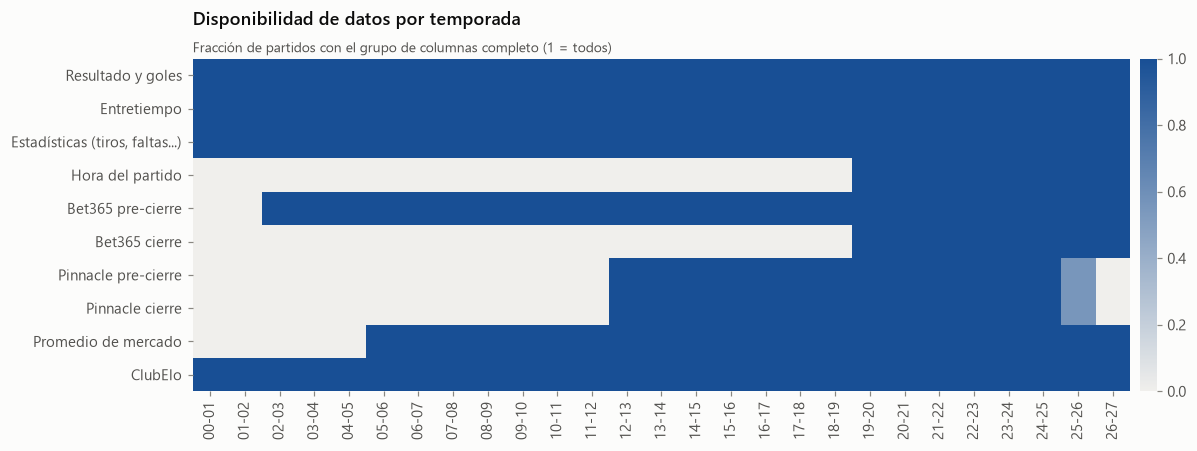

season,2000-01,2001-02,2002-03,2003-04,2004-05,2005-06,2006-07,2007-08,2008-09,2009-10,2010-11,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26,2026-27
Resultado y goles,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Entretiempo,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
"Estadísticas (tiros, faltas...)",1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Hora del partido,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Bet365 pre-cierre,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Bet365 cierre,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Pinnacle pre-cierre,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.550,0.000
Pinnacle cierre,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.550,0.000
Promedio de mercado,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
ClubElo,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [5]:
GROUPS = {
    "Resultado y goles": ["home_goals", "away_goals", "result"],
    "Entretiempo": ["ht_home_goals", "ht_away_goals"],
    "Estadísticas (tiros, faltas...)": ["home_shots", "home_fouls", "home_corners", "home_yellow"],
    "Hora del partido": ["time"],
    "Bet365 pre-cierre": ["b365_home", "b365_draw", "b365_away"],
    "Bet365 cierre": ["b365c_home", "b365c_draw", "b365c_away"],
    "Pinnacle pre-cierre": ["ps_home", "ps_draw", "ps_away"],
    "Pinnacle cierre": ["psc_home", "psc_draw", "psc_away"],
    "Promedio de mercado": ["avg_home", "avg_draw", "avg_away"],
    "ClubElo": ["clubelo_home", "clubelo_away"],
}
availability = pd.DataFrame({
    name: pl.groupby("season")[cols].apply(lambda g: g.notna().all(axis=1).mean())
    for name, cols in GROUPS.items()
})
fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(availability.T.values, aspect="auto", cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("avail", ["#f0efec", viz.SEQUENTIAL_BLUE[-2]]), vmin=0, vmax=1)
ax.set_yticks(range(len(GROUPS)), availability.columns)
ax.set_xticks(range(len(availability)), [s[2:] for s in availability.index], rotation=90)
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("Disponibilidad de datos por temporada")
viz.subtitle(ax, "Fracción de partidos con el grupo de columnas completo (1 = todos)")
cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01); cb.outline.set_visible(False)
fig.tight_layout(); fig.savefig(FIG_DIR / "eda_availability.png")
plt.show()
availability.round(2).T

**Lectura:**
* **Bet365 pre-cierre** existe desde 2002-03 → es el benchmark de mercado con mayor cobertura (las dos primeras temporadas no tienen cuotas de Bet365).
* **Pinnacle** (pre-cierre y cierre) desde 2012-13; en 2025-26 cubre solo el 55% de los partidos y en 2026-27 no aparece.
  El benchmark "exigente" contra Pinnacle cierre solo puede evaluarse donde exista.
* **Hora del partido** solo desde 2019-20: antes no se pueden ordenar partidos del mismo día. No es problema para
  las features si todo se calcula con partidos de **días anteriores** (regla que adoptamos; ver sección 9).
* **ClubElo** no tiene huecos en la Premier.

## 3 · Duplicados, integridad y auditoría de la fuente

Chequeos automáticos del pipeline (`src/data/football_data.py`, `src/data/checks.py`), que abortan la carga si fallan:
el resultado coincide con los goles; los goles al entretiempo no superan los finales; no hay duplicados; cada temporada
cerrada tiene 20 equipos que juegan 19 partidos de local y 19 de visitante contra todos.

**Filas con campos extra.** En E0 2003-04 y 2004-05, los últimos 45 partidos de cada temporada tienen más campos que
el encabezado (Football-Data agregó casas de apuestas a mitad de temporada). El parser las conserva descartando los
campos sobrantes, que siempre van al final.

In [6]:
print("Filas con campos extra recuperadas:", quality["rows_with_extra_fields_recovered"])
print("Tríos de cuotas inválidos anulados:", len(quality["invalid_odds_set_to_nan"]), "(todos de Championship)")
print("Duplicados exactos:", pl.duplicated().sum(), "| duplicados por (fecha, local, visitante):",
      pl.duplicated(["date", "home_team", "away_team"]).sum(), "| match_id repetidos:", pl.match_id.duplicated().sum())
print("Partidos donde un equipo juega dos veces el mismo día:",
      pd.concat([pl[["date", "home_team"]].set_axis(["date", "team"], axis=1),
                 pl[["date", "away_team"]].set_axis(["date", "team"], axis=1)]).duplicated().sum())

Filas con campos extra recuperadas: {'E0 2003-04': 45, 'E0 2004-05': 45, 'E1 2002-03': 32, 'E1 2004-05': 160}
Tríos de cuotas inválidos anulados: 3 (todos de Championship)
Duplicados exactos: 0 | duplicados por (fecha, local, visitante): 0 | match_id repetidos: 0
Partidos donde un equipo juega dos veces el mismo día: 0


### 3.1 · Comparación con el dataset derivado anterior

Los partidos que faltaban eran **exactamente** esas filas con campos extra (abril-mayo de 2004 y 2005), más los
partidos de 2026-27 posteriores al corte de ese dataset. En los partidos comunes, los goles coinciden en el 100%.

La tabla de abajo muestra a qué columna de Football-Data corresponde `OddHome` en cada temporada: **no es siempre
Bet365.** Entre 2019-20 y 2024-25 es el promedio del mercado, y en 2000-02 es otra casa (Gamebookers). Usarla como
benchmark mezclaría definiciones distintas entre train y test; por eso el proyecto toma las cuotas directamente de
Football-Data con una definición fija.

In [7]:
# Comparación con el dataset derivado que se usaba antes (Club Football Match Data, A. Gábor).
# Opcional: solo corre si data/raw/Matches.csv sigue descargado.
gabor_path = RAW_DIR / "Matches.csv"
if gabor_path.exists():
    gabor = pd.read_csv(gabor_path, low_memory=False)
    gabor = gabor[gabor.Division == "E0"].copy()
    gabor["date"] = pd.to_datetime(gabor.MatchDate)
    for col in ("HomeTeam", "AwayTeam"):
        gabor[col] = gabor[col].replace({"Nottm Forest": "Nott'm Forest"})
    merged = pl.merge(gabor, left_on=["date", "home_team", "away_team"], right_on=["date", "HomeTeam", "AwayTeam"],
                      how="left", indicator=True)
    missing = merged[merged._merge == "left_only"]
    print(f"Partidos de Football-Data ausentes en el dataset derivado: {len(missing)}")
    print(missing.groupby(["season", missing.date.dt.strftime("%Y-%m")]).size().to_string())
    both = merged[merged._merge == "both"]
    print("\nDiferencias de goles en los partidos comunes:",
          int(((both.home_goals != both.FTHome) | (both.away_goals != both.FTAway)).sum()))
    # ¿A qué columna de Football-Data corresponde "OddHome"? (el README dice Bet365)
    candidates = {"Bet365 pre-cierre": "b365_home", "Bet365 cierre": "b365c_home", "Promedio mercado": "avg_home"}
    source = pd.DataFrame({
        name: both.groupby("season").apply(lambda g, c=col: np.isclose(g[c], g.OddHome).mean())
        for name, col in candidates.items()
    })
    display(source.style.format("{:.0%}").background_gradient(cmap="Blues", vmin=0, vmax=1))
else:
    print("data/raw/Matches.csv no está: se omite la comparación con el dataset derivado.")

Partidos de Football-Data ausentes en el dataset derivado: 120
season   date   
2003-04  2004-04    32
         2004-05    13
2004-05  2005-04    19
         2005-05    26
2026-27  2026-09    30

Diferencias de goles en los partidos comunes: 0


,Bet365 pre-cierre,Bet365 cierre,Promedio mercado
season,,,
2000-01,0%,0%,0%
2001-02,0%,0%,0%
2002-03,62%,0%,0%
2003-04,84%,0%,0%
2004-05,98%,0%,0%
2005-06,100%,0%,8%
2006-07,100%,0%,9%
2007-08,100%,0%,10%
2008-09,100%,0%,8%


## 4 · Consistencia de nombres de equipo

Crítico para posición en tabla, head-to-head y Elo: si un club aparece con dos nombres, se parte en dos equipos.
Football-Data usa nombres estables; la única variante encontrada fue `Nottm Forest` (en el dataset derivado,
2022-23 a 2024-25) frente a `Nott'm Forest`, resuelta en `src/data/teams.py`. Los nombres de la tabla de ClubElo
coinciden al 100% con los de Football-Data (verificado en el pipeline: 0 partidos de Premier sin Elo).

In [8]:
team_seasons = pd.concat([pl[["season", "home_team"]].set_axis(["season", "team"], axis=1),
                          pl[["season", "away_team"]].set_axis(["season", "team"], axis=1)]).drop_duplicates()
per_season = team_seasons.groupby("season").size()
print("Equipos por temporada:", per_season.unique(), "| equipos distintos en 2000-2026:", team_seasons.team.nunique())
seasons_per_team = team_seasons.groupby("team").size().sort_values(ascending=False)
print("Siempre presentes:", list(seasons_per_team[seasons_per_team == pl.season.nunique()].index))
seasons_per_team.to_frame("temporadas en Premier").T

Equipos por temporada: [20] | equipos distintos en 2000-2026: 46
Siempre presentes: ['Arsenal', 'Chelsea', 'Tottenham', 'Man United', 'Liverpool', 'Everton']


team,Arsenal,Chelsea,Tottenham,Man United,Liverpool,Everton,Man City,Newcastle,Aston Villa,West Ham,Fulham,Southampton,Sunderland,Crystal Palace,Leicester,West Brom,Wolves,Blackburn,Bolton,Bournemouth,Brighton,Burnley,Middlesbrough,Stoke,Leeds,Wigan,Birmingham,Charlton,Portsmouth,Norwich,Watford,Swansea,Hull,Brentford,Nott'm Forest,Ipswich,Sheffield United,Reading,QPR,Derby,Cardiff,Coventry,Huddersfield,Blackpool,Bradford,Luton
temporadas en Premier,27,27,27,27,27,27,26,25,24,23,20,17,16,15,13,13,12,11,11,10,10,10,10,10,9,8,7,7,7,7,7,7,6,6,5,4,4,3,3,3,2,2,2,1,1,1


## 5 · Completitud por temporada

Las 26 temporadas cerradas tienen los 380 partidos esperados. La 2026-27 está en curso. Nótese 2019-20: termina el
**26/07/2020** por la pandemia, así que la temporada de cada partido se toma del archivo de origen y **nunca se
deriva del mes** (una regla "agosto a julio" asignaría mal esas fechas).

In [9]:
completeness = pl.groupby("season").agg(partidos=("match_id", "size"), desde=("date", "min"), hasta=("date", "max"))
completeness["esperados"] = 380
completeness.T

season,2000-01,2001-02,2002-03,2003-04,2004-05,2005-06,2006-07,2007-08,2008-09,2009-10,2010-11,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26,2026-27
partidos,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,50
desde,2000-08-19 00:00:00,2001-08-18 00:00:00,2002-08-17 00:00:00,2003-08-16 00:00:00,2004-08-14 00:00:00,2005-08-13 00:00:00,2006-08-19 00:00:00,2007-08-11 00:00:00,2008-08-16 00:00:00,2009-08-15 00:00:00,2010-08-14 00:00:00,2011-08-13 00:00:00,2012-08-18 00:00:00,2013-08-17 00:00:00,2014-08-16 00:00:00,2015-08-08 00:00:00,2016-08-13 00:00:00,2017-08-11 00:00:00,2018-08-10 00:00:00,2019-08-09 00:00:00,2020-09-12 00:00:00,2021-08-13 00:00:00,2022-08-05 00:00:00,2023-08-11 00:00:00,2024-08-16 00:00:00,2025-08-15 00:00:00,2026-08-21 00:00:00
hasta,2001-05-19 00:00:00,2002-05-11 00:00:00,2003-05-11 00:00:00,2004-05-15 00:00:00,2005-05-15 00:00:00,2006-05-07 00:00:00,2007-05-13 00:00:00,2008-05-11 00:00:00,2009-05-24 00:00:00,2010-05-09 00:00:00,2011-05-22 00:00:00,2012-05-13 00:00:00,2013-05-19 00:00:00,2014-05-11 00:00:00,2015-05-24 00:00:00,2016-05-17 00:00:00,2017-05-21 00:00:00,2018-05-13 00:00:00,2019-05-12 00:00:00,2020-07-26 00:00:00,2021-05-23 00:00:00,2022-05-22 00:00:00,2023-05-28 00:00:00,2024-05-19 00:00:00,2025-05-25 00:00:00,2026-05-24 00:00:00,2026-09-20 00:00:00
esperados,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380


## 6 · Auditoría de fuga temporal en las columnas "pre-partido"

Que una columna esté documentada como pre-partido no alcanza: hay que comprobarlo.

**Elo de ClubElo.** Se asigna a cada partido el último snapshot con fecha **≤** fecha del partido. El riesgo: que el
snapshot del mismo día ya incluya ese resultado. Test: para partidos jugados justo un día de snapshot, comparar el
cambio de Elo **antes** (snapshot previo → snapshot del día) y **después** (snapshot del día → siguiente) según los
puntos obtenidos. Si hubiera fuga, el cambio "antes" dependería del resultado.

In [10]:
# ¿El snapshot de ClubElo del día D ya incluye los partidos jugados el día D?
# Si los incluyera, usar "último snapshot con fecha <= D" filtraría el resultado.
# Test: para partidos jugados justo un día de snapshot, comparar el cambio de Elo
# ANTES (snapshot previo -> snapshot D) y DESPUÉS (snapshot D -> snapshot siguiente)
# según los puntos que el equipo sacó en ese partido. Se usan todas las divisiones
# inglesas del dataset procesado (E0+E1) y solo snapshots de ClubElo real (< 15/06/2025).
snap = pd.read_csv(CLUBELO_SNAPSHOTS_PATH, parse_dates=["date"])
snap = snap[(snap.country == "ENG") & (snap.date < "2025-06-15")]
snap_dates = np.sort(snap.date.unique())
elo_at = snap.set_index(["club", "date"]).elo
prev_snap = dict(zip(snap_dates[1:], snap_dates[:-1])); next_snap = dict(zip(snap_dates[:-1], snap_dates[1:]))
points = {"H": (3, 0), "D": (1, 1), "A": (0, 3)}
rows = []
for m in all_matches[all_matches.date.isin(snap_dates)].itertuples():
    for team, pts in zip((m.home_team, m.away_team), points[m.result]):
        try:
            before = elo_at[(team, m.date)] - elo_at[(team, prev_snap[m.date])]
            after = elo_at[(team, next_snap[m.date])] - elo_at[(team, m.date)]
        except KeyError:
            continue
        rows.append((pts, before, after))
elo_test = pd.DataFrame(rows, columns=["puntos", "cambio_antes", "cambio_despues"])
print(f"{len(elo_test):,} equipo-partidos jugados un día de snapshot")
elo_test.groupby("puntos")[["cambio_antes", "cambio_despues"]].agg(["mean", "count"]).round(2)

3,574 equipo-partidos jugados un día de snapshot


cambio_antes       cambio_despues      
               mean count           mean count
puntos                                        
0            -0.110  1316         -8.590  1316
1             0.150   937          0.090   937
3             0.510  1321          8.030  1321

**Resultado: no hay fuga.** El cambio "antes" es prácticamente cero sea cual sea el resultado (±0,5 puntos),
mientras que el cambio "después" refleja el resultado con claridad (−8,6 si perdió, +8,0 si ganó). El snapshot de un
día no incorpora los partidos de ese día.

**Limitaciones del Elo de ClubElo que quedan documentadas:** (1) puede tener hasta ~15 días de antigüedad
(snapshots bimensuales); (2) desde el 15/06/2025 no es ClubElo sino una continuación provisional sin metodología
publicada (430 partidos de Premier marcados en `clubelo_provisional`). Ambas cosas motivan calcular un **Elo propio**,
partido a partido, en feature engineering.

**Cuotas.** Las pre-cierre se toman el viernes por la tarde (partidos de fin de semana) o el martes (mitad de semana)
según [notes.txt](https://www.football-data.co.uk/notes.txt): son información disponible antes del partido.

## 7 · Distribuciones

### 7.1 · Goles: ¿es razonable un modelo de Poisson?

In [11]:
goals = pl[["home_goals", "away_goals"]].astype(int)
summary = pd.DataFrame({
    "media": goals.mean(), "varianza": goals.var(), "índice de dispersión (var/media)": goals.var() / goals.mean()
})
print("Correlación de Pearson goles local vs visitante:", round(goals.home_goals.corr(goals.away_goals), 3))
summary

Correlación de Pearson goles local vs visitante: -0.082


,media,varianza,índice de dispersión (var/media)
home_goals,1.535,1.696,1.105
away_goals,1.185,1.331,1.124


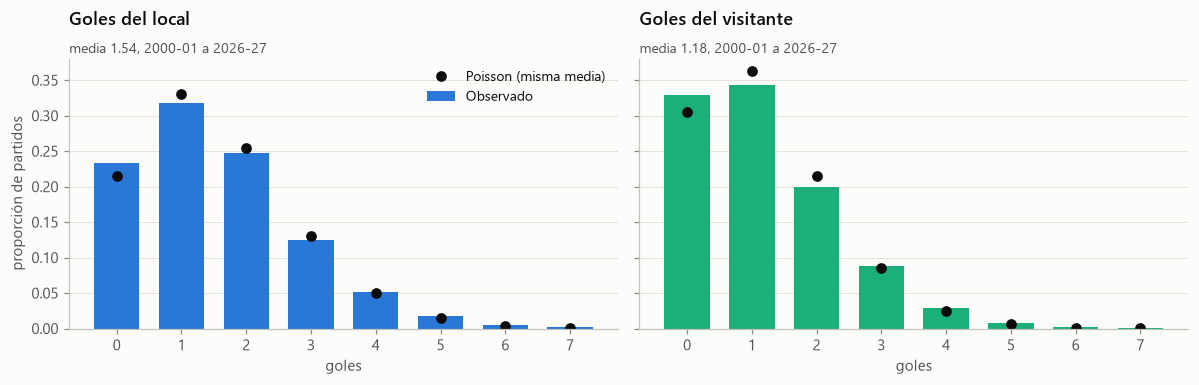

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
k = np.arange(0, 8)
for ax, side, color, label in zip(axes, ["home_goals", "away_goals"], [viz.BLUE, viz.AQUA], ["local", "visitante"]):
    obs = goals[side].value_counts(normalize=True).reindex(k, fill_value=0)
    ax.bar(k, obs.values, width=0.7, color=color, label="Observado")
    ax.plot(k, stats.poisson.pmf(k, goals[side].mean()), "o", color=viz.INK, markersize=6, label="Poisson (misma media)")
    ax.set_title(f"Goles del {label}")
    viz.subtitle(ax, f"media {goals[side].mean():.2f}, 2000-01 a 2026-27")
    ax.set_xticks(k); ax.set_xlabel("goles")
axes[0].set_ylabel("proporción de partidos"); axes[0].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "eda_goals_poisson.png"); plt.show()

* El local convierte en promedio **1,54** goles y el visitante **1,19**.
* Índice de dispersión (varianza/media) de **1,10** y **1,12**: sobredispersión leve. Es lo esperable aunque los goles de
  cada partido sean Poisson, porque acá se mezclan equipos de fuerzas muy distintas (una mezcla de Poisson con medias
  distintas tiene varianza mayor que su media). El chequeo relevante es **condicional al modelo**, y se hará después de
  ajustarlo.
* Correlación local-visitante de **−0,08**: débil, pero no nula.

**Marcadores bajos.** Dixon y Coles (1997, *Journal of the Royal Statistical Society C*, 46(2)) propusieron corregir la
independencia del modelo de Poisson en los marcadores 0-0, 1-0, 0-1 y 1-1. Chequeo crudo: frecuencia observada contra la
esperada con goles Poisson independientes con la media de cada temporada.

In [13]:
# Dixon & Coles (1997) observaron que un modelo de Poisson independiente subestima
# ciertos marcadores bajos (0-0, 1-1) y sobreestima otros (1-0, 0-1). Chequeo crudo:
# frecuencia observada vs la esperada si los goles fueran Poisson independientes
# con la media de CADA temporada (para no confundir con cambios de época).
obs_counts, exp_counts = {}, {}
for season, g in pl.groupby("season"):
    lh, la = g.home_goals.mean(), g.away_goals.mean()
    for h, a in [(0, 0), (1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 1), (1, 2), (2, 2)]:
        obs_counts[(h, a)] = obs_counts.get((h, a), 0) + ((g.home_goals == h) & (g.away_goals == a)).sum()
        exp_counts[(h, a)] = exp_counts.get((h, a), 0) + len(g) * stats.poisson.pmf(h, lh) * stats.poisson.pmf(a, la)
low = pd.DataFrame({"observados": obs_counts, "esperados_poisson_indep": exp_counts})
low["obs/esp"] = low.observados / low.esperados_poisson_indep
# z aproximado (conteo ~ Poisson): cuántos desvíos estándar se aleja lo observado de lo esperado.
low["z"] = (low.observados - low.esperados_poisson_indep) / np.sqrt(low.esperados_poisson_indep)
low.index = [f"{h}-{a}" for h, a in low.index]
low.round(2)

,observados,esperados_poisson_indep,obs/esp,z
0-0,733,662.390,1.110,2.740
1-0,984,1010.320,0.970,-0.830
0-1,723,775.130,0.930,-1.870
1-1,1101,1183.840,0.930,-2.410
2-0,810,772.720,1.050,1.340
0-2,467,457.280,1.020,0.450
2-1,863,906.790,0.950,-1.450
1-2,645,699.370,0.920,-2.060
2-2,527,536.550,0.980,-0.410


**Lectura honesta:** el 0-0 aparece un 11% más de lo esperado (z ≈ +2,8) y 1-0/0-1 algo menos, en línea con la
motivación de Dixon-Coles. Pero el 1-1 (z ≈ −2,4) y el 1-2 (z ≈ −2,1) aparecen **menos** de lo esperado, al revés de lo que corrige ese
ajuste. Como este chequeo ignora las diferencias de fuerza entre equipos, no es concluyente: la corrección de
Dixon-Coles se evaluará como una **variante del modelo, validada fuera de muestra**, no se asumirá.

Goles promedio por temporada: estables en torno a 1,5 (local) y 1,1-1,2 (visitante), con dos anomalías visibles en el
visitante: 2020-21 (sin público) y 2023-24.

In [14]:
by_season = pl.groupby("season")[["home_goals", "away_goals"]].mean()
by_season.round(2).T

season,2000-01,2001-02,2002-03,2003-04,2004-05,2005-06,2006-07,2007-08,2008-09,2009-10,2010-11,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26,2026-27
home_goals,1.540,1.470,1.500,1.510,1.500,1.460,1.450,1.530,1.400,1.700,1.620,1.590,1.560,1.570,1.470,1.490,1.600,1.530,1.570,1.520,1.350,1.510,1.630,1.800,1.510,1.530,1.520
away_goals,1.070,1.170,1.130,1.160,1.070,1.020,1.000,1.110,1.080,1.070,1.170,1.220,1.240,1.190,1.090,1.210,1.200,1.150,1.250,1.210,1.340,1.310,1.220,1.480,1.420,1.220,1.300


### 7.2 · Elo

count   19860.000
mean     1732.100
std       113.100
min      1475.500
25%      1648.500
50%      1706.100
75%      1807.400
max      2090.100


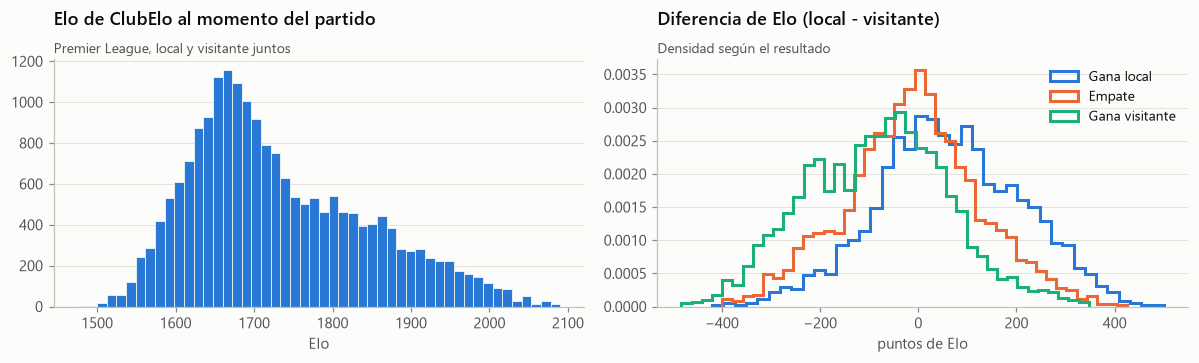

Valores de Elo con |z| > 3: 23


In [15]:
elo_long = pd.concat([pl.clubelo_home, pl.clubelo_away])
print(elo_long.describe().round(1).to_string())
diff = pl.clubelo_home - pl.clubelo_away
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(elo_long, bins=50, color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=0.5)
axes[0].set_title("Elo de ClubElo al momento del partido"); axes[0].set_xlabel("Elo")
viz.subtitle(axes[0], "Premier League, local y visitante juntos")
res = pl.result
for outcome, label in [("H", "Gana local"), ("D", "Empate"), ("A", "Gana visitante")]:
    axes[1].hist(diff[res == outcome], bins=40, histtype="step", linewidth=2, color=viz.OUTCOME_COLORS[outcome], label=label, density=True)
axes[1].set_title("Diferencia de Elo (local - visitante)"); axes[1].set_xlabel("puntos de Elo"); axes[1].legend()
viz.subtitle(axes[1], "Densidad según el resultado")
fig.tight_layout(); plt.show()
z = np.abs(stats.zscore(elo_long.dropna()))
print("Valores de Elo con |z| > 3:", int((z > 3).sum()))

Los 23 valores con |z| > 3 son equipos de élite reales (el máximo, ~2090, corresponde al Manchester City de la era
reciente), no errores. La diferencia de Elo separa bien los resultados: es la señal pre-partido más obvia.

### 7.3 · Cuotas: margen de la casa

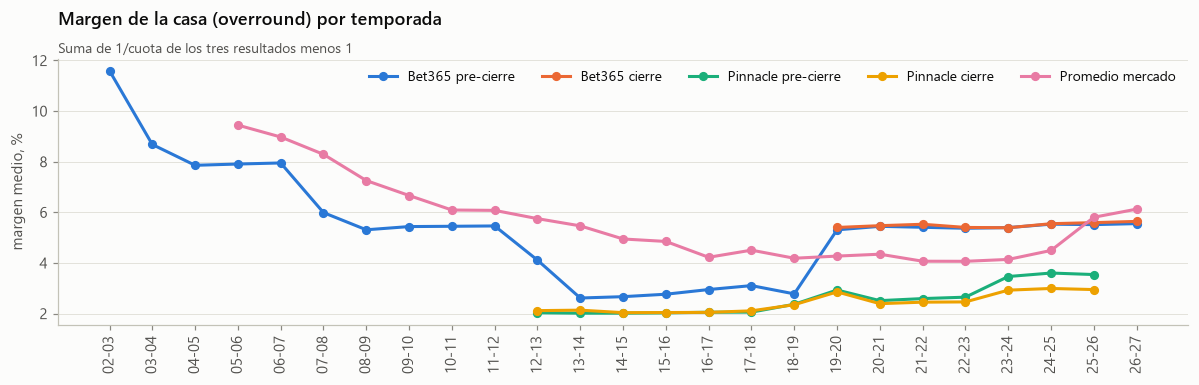

season,2002-03,2003-04,2004-05,2005-06,2006-07,2007-08,2008-09,2009-10,2010-11,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26,2026-27
Bet365 pre-cierre,11.600,8.680,7.860,7.910,7.950,5.990,5.310,5.440,5.450,5.460,4.110,2.620,2.670,2.770,2.950,3.110,2.780,5.310,5.450,5.410,5.370,5.400,5.530,5.520,5.550
Bet365 cierre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.400,5.470,5.530,5.400,5.390,5.550,5.590,5.640
Pinnacle pre-cierre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.030,2.020,2.020,2.030,2.050,2.060,2.370,2.930,2.510,2.590,2.650,3.460,3.600,3.540,NaN
Pinnacle cierre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.120,2.140,2.040,2.040,2.050,2.110,2.350,2.860,2.390,2.450,2.460,2.930,2.990,2.950,NaN
Promedio mercado,NaN,NaN,NaN,9.450,8.980,8.290,7.260,6.670,6.090,6.080,5.750,5.470,4.950,4.850,4.220,4.510,4.190,4.270,4.350,4.070,4.070,4.140,4.490,5.810,6.130


In [16]:
BOOKS = {"Bet365 pre-cierre": "b365", "Bet365 cierre": "b365c", "Pinnacle pre-cierre": "ps",
         "Pinnacle cierre": "psc", "Promedio mercado": "avg"}
margins = {}
for name, b in BOOKS.items():
    odds = pl[[f"{b}_home", f"{b}_draw", f"{b}_away"]].dropna()
    margins[name] = (booksum(odds.values) - 1).__array__()
    margins[name] = pd.Series(margins[name], index=odds.index).groupby(pl.loc[odds.index, "season"]).mean()
margins = pd.DataFrame(margins).mul(100)
fig, ax = plt.subplots(figsize=(11, 3.6))
for (name, series), color in zip(margins.items(), viz.CATEGORICAL):
    s = series.dropna(); ax.plot([x[2:] for x in s.index], s.values, marker="o", color=color, label=name)
ax.set_title("Margen de la casa (overround) por temporada"); ax.set_ylabel("margen medio, %")
viz.subtitle(ax, "Suma de 1/cuota de los tres resultados menos 1")
ax.tick_params(axis="x", rotation=90); ax.legend(ncol=5, loc="upper right")
fig.tight_layout(); plt.show()
margins.round(2).T

In [17]:
b365 = pl[["b365_home", "b365_draw", "b365_away"]]
print(b365.describe().round(2).to_string())
print("\nCuotas locales más altas (sorpresas potenciales, no errores):")
pl.loc[b365.b365_home.nlargest(5).index, ["date", "home_team", "away_team", "b365_home", "b365_draw", "b365_away", "result"]]

       b365_home  b365_draw  b365_away
count   9170.000   9170.000   9170.000
mean       2.760      4.000      4.700
std        1.920      1.180      3.900
min        1.060      2.500      1.120
25%        1.660      3.300      2.380
50%        2.200      3.600      3.400
75%        3.000      4.200      5.500
max       23.000     17.000     41.000

Cuotas locales más altas (sorpresas potenciales, no errores):


,date,home_team,away_team,b365_home,b365_draw,b365_away,result
6892,2018-09-22,Cardiff,Man City,23.000,8.000,1.160,A
7197,2019-04-28,Burnley,Man City,23.000,9.000,1.140,A
7069,2019-01-20,Huddersfield,Man City,21.000,8.500,1.160,A
7147,2019-03-30,Fulham,Man City,21.000,11.000,1.120,A
7074,2019-01-29,Newcastle,Man City,19.000,8.000,1.180,H


* El margen de Bet365 cayó de ~12% (2002-03) a ~3% (2013-2019) y **volvió a ~5,4% desde 2019-20**.
* Pinnacle mantiene el menor margen (2-3,6%), coherente con su reputación de casa de margen bajo.
* Consecuencia: la probabilidad implícita cruda (1/cuota) está inflada por el margen, así que hay que **quitárselo**
  antes de comparar (sección 8).

No se detectaron cuotas imposibles en la Premier (en la Championship se anularon 3 tríos: dos con cuota `0` y uno
de Pinnacle cierre con suma de probabilidades implícitas 0,934, imposible para una sola casa).

## 8 · Hallazgo: la ventaja de local y los estadios vacíos

Eras (fechas verificadas, ver `src/eras.py`): **con público** hasta la suspensión del 13/03/2020; **sin público**
desde el reinicio del 17/06/2020 hasta el 23/05/2021; **con público** desde el 13/08/2021 (aforo completo).
Intervalos de confianza por bootstrap (10.000 remuestreos).

In [18]:
pl["era"] = eras.assign_era(pl.date)
pl["partial_crowd"] = eras.in_partial_crowd_window(pl.date)
pl["home_points"] = pl.result.map({"H": 3, "D": 1, "A": 0})
pl["goal_diff"] = (pl.home_goals - pl.away_goals).astype(float)

def era_stats(df):
    return pd.Series({
        "partidos": len(df),
        "% gana local": (df.result == "H").mean() * 100,
        "% empate": (df.result == "D").mean() * 100,
        "% gana visitante": (df.result == "A").mean() * 100,
        "dif. de gol local": df.goal_diff.mean(),
        "puntos local - puntos visitante": (df.home_points - df.result.map({"H": 0, "D": 1, "A": 3})).mean(),
    })

def bootstrap_ci(values, n_boot=10_000, stat=np.mean):
    values = np.asarray(values, dtype=float)
    idx = RNG.integers(0, len(values), size=(n_boot, len(values)))
    boots = stat(values[idx], axis=1)
    return np.percentile(boots, [2.5, 97.5])

era_table = pl.groupby("era").apply(era_stats).reindex(eras.ERA_ORDER)
for metric, series in [("dif. de gol local", "goal_diff")]:
    cis = {e: bootstrap_ci(pl.loc[pl.era == e, series]) for e in eras.ERA_ORDER}
    era_table["IC95% dif. gol"] = [f"[{lo:.2f}, {hi:.2f}]" for lo, hi in cis.values()]
cis_home = {e: bootstrap_ci((pl.loc[pl.era == e, "result"] == "H").astype(float)) * 100 for e in eras.ERA_ORDER}
era_table["IC95% % gana local"] = [f"[{lo:.1f}, {hi:.1f}]" for lo, hi in cis_home.values()]
print("Partidos fuera de las tres eras (entre suspensión y reinicio, o en el receso 2021):", pl.era.isna().sum())
era_table

Partidos fuera de las tres eras (entre suspensión y reinicio, o en el receso 2021): 0


,partidos,% gana local,% empate,% gana visitante,dif. de gol local,puntos local - puntos visitante,IC95% dif. gol,IC95% % gana local
era,,,,,,,,
Con público (hasta mar-2020),7508.000,46.430,25.226,28.343,0.389,0.543,"[0.35, 0.43]","[45.3, 47.5]"
Sin público (jun-2020 a may-2021),472.000,39.619,21.822,38.559,0.081,0.032,"[-0.09, 0.26]","[35.2, 43.9]"
Con público (desde ago-2021),1950.000,43.949,24.103,31.949,0.267,0.360,"[0.18, 0.35]","[41.8, 46.2]"


**El hallazgo:**
* Con público, antes de la pandemia, el local ganaba el **46%** de los partidos y sacaba **+0,39** goles de diferencia.
* **Sin público**, la ventaja prácticamente desaparece: **+0,08** goles (IC 95% cruza el 0), y el local y el visitante
  ganan casi lo mismo (40% contra 39%).
* Con el público de vuelta, la ventaja **regresa, pero más chica** que antes: **+0,27** goles.

Lo de abajo comprueba que no es ruido ni un artefacto de las ventanas con público parcial.

In [19]:
# Sensibilidad: excluir de la era "sin público" las dos ventanas con público limitado.
strict = pl[(pl.era == eras.NO_CROWDS) & ~pl.partial_crowd]
print(f"Era sin público estricta: {len(strict)} partidos (se excluyen {int((pl.era == eras.NO_CROWDS).sum() - len(strict))})")
print(era_stats(strict).round(2).to_string())
lo, hi = bootstrap_ci(strict.goal_diff); print(f"IC95% dif. gol: [{lo:.2f}, {hi:.2f}]")
# Test de permutación: ¿la diferencia de gol local sin público es distinta de la de antes?
a = pl.loc[pl.era == eras.PRE_PANDEMIC, "goal_diff"].values; b = pl.loc[pl.era == eras.NO_CROWDS, "goal_diff"].values
res = stats.permutation_test((a, b), lambda x, y: np.mean(x) - np.mean(y), n_resamples=20_000, random_state=0)
print(f"\nPre-pandemia vs sin público: diferencia {a.mean() - b.mean():.3f} goles, p = {res.pvalue:.4f} (permutación, dos colas)")
c = pl.loc[pl.era == eras.FULL_CROWDS, "goal_diff"].values
res2 = stats.permutation_test((a, c), lambda x, y: np.mean(x) - np.mean(y), n_resamples=20_000, random_state=0)
print(f"Pre-pandemia vs con público actual: diferencia {a.mean() - c.mean():.3f} goles, p = {res2.pvalue:.4f}")

Era sin público estricta: 387 partidos (se excluyen 85)
partidos                          387.000
% gana local                       39.280
% empate                           20.930
% gana visitante                   39.790
dif. de gol local                   0.070
puntos local - puntos visitante    -0.020


IC95% dif. gol: [-0.12, 0.26]



Pre-pandemia vs sin público: diferencia 0.309 goles, p = 0.0004 (permutación, dos colas)


Pre-pandemia vs con público actual: diferencia 0.122 goles, p = 0.0073


* Excluyendo las ventanas con público limitado, la conclusión no cambia (+0,07 goles).
* La caída sin público es estadísticamente clara (p < 0,001, test de permutación).
* La ventaja actual es menor que la previa a la pandemia (p ≈ 0,007).

**Límites de la interpretación:** la era sin público tiene solo 472 partidos (de ahí el IC ancho), y la
comparación es observacional: coincidió con otros cambios (calendario comprimido, cinco cambios, sin pretemporada).
El dataset no permite atribuir el efecto solo al público.

**Implicancia para el modelo:** la ventaja de local **no es constante en el tiempo**. Un parámetro de localía fijo
estimado con 20 años de datos la sobreestimaría para el presente. Esto justifica ponderar más los partidos recientes
(Dixon-Coles usan un decaimiento temporal exponencial) y tratar la era sin público de forma explícita.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


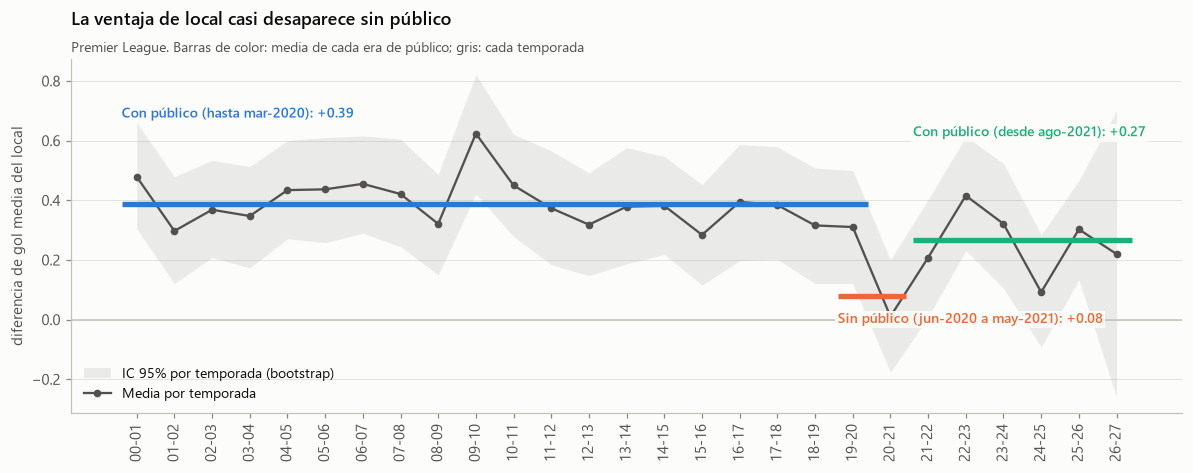

In [20]:
season_hadv = pl.groupby("season").goal_diff.mean()
season_ci = {s: bootstrap_ci(g.goal_diff, n_boot=4000) for s, g in pl.groupby("season")}
x = np.arange(len(season_hadv)); pos = dict(zip(season_hadv.index, x))
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.fill_between(x, [season_ci[s][0] for s in season_hadv.index], [season_ci[s][1] for s in season_hadv.index],
                color=viz.MUTED, alpha=0.15, linewidth=0, label="IC 95% por temporada (bootstrap)")
ax.plot(x, season_hadv.values, marker="o", color=viz.INK_2, linewidth=1.5, markersize=4, label="Media por temporada")
ax.axhline(0, color=viz.AXIS, linewidth=1)
# Media de cada era como segmento sobre las temporadas que abarca (2019-20 y 2020-21 comparten eras).
spans = {eras.PRE_PANDEMIC: ("2000-01", "2019-20"), eras.NO_CROWDS: ("2019-20", "2020-21"), eras.FULL_CROWDS: ("2021-22", season_hadv.index[-1])}
offsets = {eras.PRE_PANDEMIC: 0.3, eras.NO_CROWDS: -0.08, eras.FULL_CROWDS: 0.36}
for era, (a, b) in spans.items():
    mean = pl.loc[pl.era == era, "goal_diff"].mean()
    ax.hlines(mean, pos[a] - 0.4, pos[b] + 0.4, color=viz.ERA_COLORS[era], linewidth=3.5, zorder=3)
    ax.text(pos[a] - 0.4, mean + offsets[era], f"{era}: {mean:+.2f}", color=viz.ERA_COLORS[era], fontsize=9,
            fontweight="semibold", va="center", zorder=5,
            bbox=dict(facecolor=viz.SURFACE, edgecolor="none", pad=1.5, alpha=0.9))
ax.set_xticks(x, [s[2:] for s in season_hadv.index], rotation=90)
ax.set_title("La ventaja de local casi desaparece sin público")
ax.set_ylabel("diferencia de gol media del local")
viz.subtitle(ax, "Premier League. Barras de color: media de cada era de público; gris: cada temporada")
ax.legend(loc="lower left")
fig.tight_layout(); fig.savefig(FIG_DIR / "eda_home_advantage.png"); plt.show()

## 9 · ¿Qué tan bien calibrado está el mercado? (el benchmark a batir)

Se quita el margen con dos métodos (`src/odds.py`): **proporcional** y **Shin**. Štrumbelj (2014, *International
Journal of Forecasting* 30(4)) encontró que las probabilidades de Shin son pronósticos más precisos que la
normalización básica. Se evalúa sobre la muestra común donde existen Bet365 pre-cierre **y** Pinnacle cierre.

Métricas (`src/metrics.py`): **log loss** (métrica principal: penaliza fuerte la sobreconfianza), **Brier multiclase**,
**accuracy** y **ECE** (error de calibración esperado).

In [21]:
# Muestra común: partidos con Bet365 pre-cierre Y Pinnacle cierre (2012-13 a 2025-26).
cal = pl.dropna(subset=["b365_home", "b365_draw", "b365_away", "psc_home", "psc_draw", "psc_away"]).reset_index(drop=True)
print(f"Muestra común: {len(cal):,} partidos, {cal.season.min()} a {cal.season.max()}")
forecasts = {}
for name, b in [("Bet365 pre-cierre", "b365"), ("Pinnacle cierre", "psc")]:
    odds = cal[[f"{b}_home", f"{b}_draw", f"{b}_away"]].values
    forecasts[f"{name} · proporcional"] = proportional_probabilities(odds)
    forecasts[f"{name} · Shin"] = shin_probabilities(odds)
freq = cal.result.value_counts(normalize=True).reindex(OUTCOMES).values
forecasts["Frecuencias históricas (referencia ingenua)"] = np.tile(freq, (len(cal), 1))
market_scores = pd.DataFrame({name: summarize(p, cal.result.values) for name, p in forecasts.items()}).T
market_scores.style.format({"n": "{:,.0f}", "log_loss": "{:.4f}", "brier": "{:.4f}", "accuracy": "{:.1%}", "ece": "{:.4f}"})

Muestra común: 5,150 partidos, 2012-13 a 2025-26


,n,log_loss,brier,accuracy,ece
Bet365 pre-cierre · proporcional,"5,150",0.9561,0.5657,55.4%,0.0095
Bet365 pre-cierre · Shin,"5,150",0.9559,0.5656,55.4%,0.0094
Pinnacle cierre · proporcional,"5,150",0.9523,0.5633,55.2%,0.0107
Pinnacle cierre · Shin,"5,150",0.9522,0.5632,55.2%,0.0099
Frecuencias históricas (referencia ingenua),"5,150",1.0651,0.6441,44.7%,0.0000


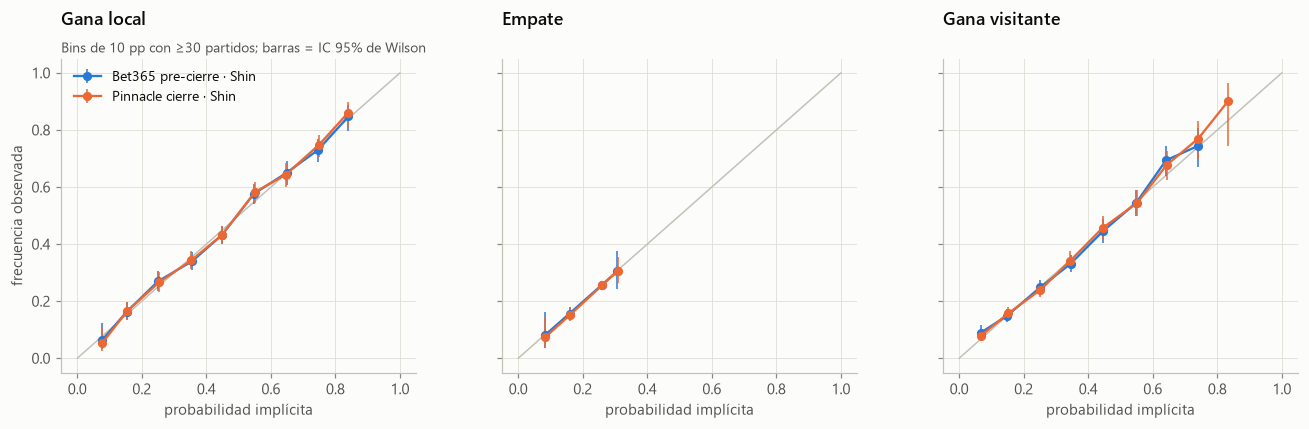

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
labels = {"H": "Gana local", "D": "Empate", "A": "Gana visitante"}
for ax, outcome in zip(axes, OUTCOMES):
    ax.plot([0, 1], [0, 1], color=viz.AXIS, linewidth=1)
    for (name, color) in [("Bet365 pre-cierre · Shin", viz.BLUE), ("Pinnacle cierre · Shin", viz.ORANGE)]:
        t = reliability_table(forecasts[name], cal.result.values, n_bins=10)
        t = t[(t.outcome == outcome) & (t.n >= 30)]
        ax.errorbar(t.mean_predicted, t.observed, yerr=[t.observed - t.ci_low, t.ci_high - t.observed],
                    fmt="o-", color=color, markersize=5, linewidth=1.5, capsize=0, elinewidth=1, label=name)
    ax.set_title(labels[outcome]); ax.set_xlabel("probabilidad implícita")
    ax.grid(True, axis="both")
axes[0].set_ylabel("frecuencia observada"); axes[0].legend(loc="upper left")
viz.subtitle(axes[0], "Bins de 10 pp con ≥30 partidos; barras = IC 95% de Wilson")
fig.tight_layout(); fig.savefig(FIG_DIR / "eda_market_calibration.png"); plt.show()

**Lectura:**
* Ambas casas están **muy bien calibradas** (ECE ≈ 0,01): sus probabilidades se corresponden con las frecuencias reales.
* El mercado supera ampliamente a la referencia ingenua (log loss 0,95-0,96 contra 1,065).
* Pinnacle cierre es algo mejor que Bet365 pre-cierre (ver abajo si la diferencia es significativa). Es lo esperable:
  la cuota de cierre incorpora la información de toda la semana (alineaciones, lesiones).
* En este mercado, Shin y el proporcional dan resultados casi idénticos.

**Qué significa para el proyecto:** superar al mercado es muy difícil. Un modelo basado solo en resultados pasados y
Elo **no tiene la información de lesiones y alineaciones** que sí tienen las cuotas de cierre. La meta realista y
honesta es acercarse a Bet365 pre-cierre (misma ventana de información: días antes del partido) y reportar la
distancia a Pinnacle cierre sin maquillarla.

In [23]:
# ¿La diferencia entre Pinnacle cierre y Bet365 pre-cierre es real o ruido? Bootstrap pareado por partido.
y = cal.result.values
def per_match_ll(p):
    return -np.log(p[np.arange(len(y)), pd.Series(y).map({"H": 0, "D": 1, "A": 2}).values])
delta = per_match_ll(forecasts["Bet365 pre-cierre · Shin"]) - per_match_ll(forecasts["Pinnacle cierre · Shin"])
lo, hi = bootstrap_ci(delta)
print(f"Log loss Bet365 pre-cierre - Pinnacle cierre: {delta.mean():.4f} (IC95% [{lo:.4f}, {hi:.4f}])")
delta_shin = per_match_ll(forecasts["Bet365 pre-cierre · proporcional"]) - per_match_ll(forecasts["Bet365 pre-cierre · Shin"])
lo, hi = bootstrap_ci(delta_shin)
print(f"Log loss proporcional - Shin (Bet365 pre-cierre): {delta_shin.mean():.5f} (IC95% [{lo:.5f}, {hi:.5f}])")

Log loss Bet365 pre-cierre - Pinnacle cierre: 0.0037 (IC95% [0.0018, 0.0057])


Log loss proporcional - Shin (Bet365 pre-cierre): 0.00014 (IC95% [-0.00042, 0.00070])


* Pinnacle cierre supera a Bet365 pre-cierre por **~0,004 de log loss**, una diferencia chica pero estadísticamente
  clara (el IC 95% no incluye el 0).
* Shin contra proporcional: diferencia **no significativa** en este mercado (IC 95% incluye el 0). Se usa Shin por el
  respaldo de la literatura, sabiendo que acá casi no cambia nada.

Las diferencias entre temporadas del log loss del mercado (de 0,89 a 1,04, tabla siguiente) son más grandes que la
diferencia entre casas: algunas temporadas son intrínsecamente más impredecibles. Por eso el modelo **siempre** se va a
comparar contra el mercado **en los mismos partidos y temporadas**, nunca con un número absoluto.

In [24]:
per_season = cal.groupby("season").apply(lambda g: pd.Series({
    "Bet365 pre-cierre": summarize(shin_probabilities(g[["b365_home", "b365_draw", "b365_away"]].values), g.result.values)["log_loss"],
    "Pinnacle cierre": summarize(shin_probabilities(g[["psc_home", "psc_draw", "psc_away"]].values), g.result.values)["log_loss"],
}))
per_season.T.round(3)

season,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
Bet365 pre-cierre,0.964,0.931,0.971,1.036,0.905,0.945,0.892,0.975,1.009,0.936,0.966,0.907,0.971,0.991
Pinnacle cierre,0.957,0.928,0.970,1.034,0.906,0.941,0.890,0.973,0.998,0.936,0.962,0.898,0.967,0.987


## 10 · Factibilidad de las features planificadas

### 10.1 · Orden temporal

In [25]:
# Orden cronológico y temporadas: las fechas de cada temporada no se solapan con otra.
spans = pl.groupby("season").date.agg(["min", "max"])
print("Temporadas solapadas:", int((spans["min"].iloc[1:].values <= spans["max"].iloc[:-1].values).sum()))
print("Dataset ordenado por fecha:", pl.date.is_monotonic_increasing)
print("Partidos sin hora:", pl.time.isna().sum(), "(la hora existe desde 2019-20; varios partidos del mismo día no se pueden ordenar entre sí antes)")
same_day = pl.groupby("date").size()
print("Días con más de un partido:", int((same_day > 1).sum()), "de", len(same_day))

Temporadas solapadas: 0
Dataset ordenado por fecha: True
Partidos sin hora: 7220 (la hora existe desde 2019-20; varios partidos del mismo día no se pueden ordenar entre sí antes)
Días con más de un partido: 1895 de 2762


Como antes de 2019-20 no hay hora, **regla anti-fuga adoptada:** las features de un partido del día *D* usan solo
partidos de días **< D** (nunca del mismo día, aunque se haya jugado antes). Se pierde muy poca información (dos
partidos del mismo equipo el mismo día no existen) y la regla es verificable.

### 10.2 · Descanso y congestión

count   19320.000
mean        7.500
std         4.800
min         2.000
25%         5.000
50%         7.000
75%         8.000
max       107.000
Partidos de liga en los últimos 14 días (incl. el actual): {1: 2460, 2: 10453, 3: 5992, 4: 943, 5: 12}


Partidos de liga en los últimos 21 días (incl. el actual): {1: 697, 2: 4074, 3: 8567, 4: 5146, 5: 1287, 6: 89}


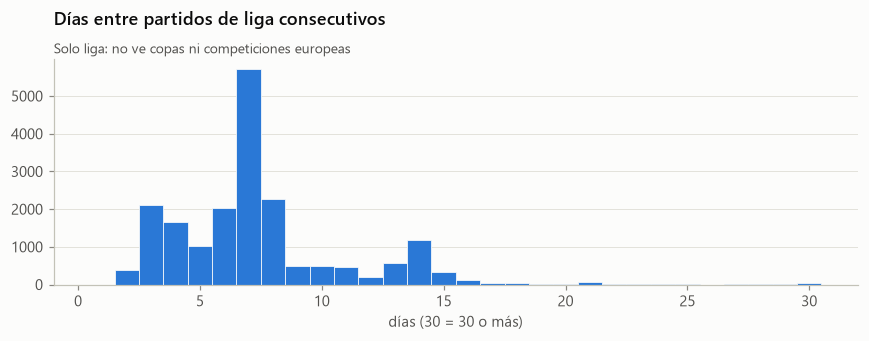

In [26]:
# Días de descanso entre partidos de LIGA consecutivos de un mismo equipo (dentro de la temporada).
long = pd.concat([
    pl[["season", "date", "home_team"]].rename(columns={"home_team": "team"}),
    pl[["season", "date", "away_team"]].rename(columns={"away_team": "team"}),
]).sort_values(["team", "date"])
long["rest_days"] = long.groupby(["team", "season"]).date.diff().dt.days
print(long.rest_days.describe().round(1).to_string())
for window in (14, 21):
    counts = (long.assign(one=1).set_index("date").groupby(["team", "season"]).one
              .rolling(f"{window}D").sum().astype(int))  # partidos de liga en la ventana (incluye el actual)
    print(f"Partidos de liga en los últimos {window} días (incl. el actual):", counts.value_counts().sort_index().to_dict())
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(long.rest_days.dropna().clip(upper=30), bins=np.arange(0.5, 31.5, 1), color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=0.5)
ax.set_title("Días entre partidos de liga consecutivos"); ax.set_xlabel("días (30 = 30 o más)")
viz.subtitle(ax, "Solo liga: no ve copas ni competiciones europeas")
fig.tight_layout(); plt.show()

* La mediana es de 7 días entre partidos de liga; el mínimo, 2. El máximo (107) es la suspensión de 2019-20.
* La ventana de **21 días** discrimina mejor que la de 14: la de 14 concentra casi todo en 2-3 partidos.

**Limitación que va documentada en el model card:** el índice solo ve partidos de **liga**. Football-Data (como el
dataset anterior) no incluye FA Cup, League Cup ni competiciones europeas, así que un equipo que jugó Champions el martes
aparece "descansado". El índice mide la congestión **de liga**, no la fatiga real.

### 10.3 · Head-to-head

In [27]:
# Head-to-head: ¿cuántos enfrentamientos previos (en liga) tiene cada partido?
def prior_meetings(df):
    pair = df.apply(lambda r: tuple(sorted((r.home_team, r.away_team))), axis=1)
    return df.assign(pair=pair).groupby("pair").cumcount()

pl["h2h_prior_e0"] = prior_meetings(pl)
both_div = all_matches.copy()
both_div["h2h_prior_all"] = prior_meetings(both_div)
pl = pl.merge(both_div[["match_id", "h2h_prior_all"]], on="match_id", how="left")
bins = [-1, 0, 2, 5, 10, 100]
labels_ = ["0", "1-2", "3-5", "6-10", ">10"]
h2h = pd.DataFrame({
    "solo Premier": pd.cut(pl.h2h_prior_e0, bins, labels=labels_).value_counts(normalize=True).sort_index(),
    "Premier + Championship": pd.cut(pl.h2h_prior_all, bins, labels=labels_).value_counts(normalize=True).sort_index(),
}).mul(100)
recent = pl[pl.season_start >= 2015]
print("Desde 2015-16, partidos con < 3 enfrentamientos previos en liga (E0+E1):", f"{(recent.h2h_prior_all < 3).mean():.1%}")
h2h.round(1)

Desde 2015-16, partidos con < 3 enfrentamientos previos en liga (E0+E1): 5.2%


,solo Premier,Premier + Championship
0,8.100,5.200
1-2,14.300,10.300
3-5,16.900,14.700
6-10,20.100,20.700
>10,40.700,48.900


Contando también los cruces en la Championship, el 95% de los partidos desde 2015-16 tiene al menos 3 antecedentes
directos en liga. Aun así, 3-5 partidos son una muestra chica: el head-to-head se va a construir con **suavizado**
(p. ej., contraído hacia lo que predice la diferencia de fuerza) y su aporte real se medirá con validación temporal;
si no mejora el log loss, se descarta.

### 10.4 · Posición en tabla

In [28]:
# Posición en tabla: en cada fecha de la temporada, ¿cuántos partidos lleva jugados cada equipo?
long_pl = long.copy()
long_pl["played_before"] = long_pl.groupby(["team", "season"]).cumcount()
print("Partidos con 0 jugados previos en la temporada (sin tabla todavía):", int((long_pl.played_before == 0).sum()), "equipo-partidos")
print("Primera fecha: la posición en tabla no existe; con < 5 partidos es muy ruidosa. Distribución de partidos previos (primeras 6 fechas):")
long_pl.played_before.value_counts().sort_index().head(6).to_dict()

Partidos con 0 jugados previos en la temporada (sin tabla todavía): 540 equipo-partidos
Primera fecha: la posición en tabla no existe; con < 5 partidos es muy ruidosa. Distribución de partidos previos (primeras 6 fechas):


{0: 540, 1: 540, 2: 540, 3: 540, 4: 540, 5: 520}

En la primera fecha no existe tabla y en las primeras fechas es muy ruidosa. Se va a usar **puntos por partido**
(más estable que la posición cuando los equipos llevan distinta cantidad de partidos) con un valor inicial explícito
y un indicador de "pocos partidos jugados", en lugar de imputar.

## 11 · Conclusiones y decisiones para feature engineering

1. **Datos base:** Football-Data.co.uk, 9.930 partidos de Premier (26 temporadas completas + 2026-27 en curso) y 14.447
   de Championship. Sin duplicados, sin inconsistencias resultado/goles, 90 partidos recuperados frente al dataset anterior.
2. **Anti-fuga:** toda feature del día *D* se calcula con partidos de días < *D*. Las estadísticas del propio partido
   (goles, tiros, tarjetas...) nunca entran como feature del mismo partido.
3. **Elo:** el de ClubElo no tiene fuga, pero es bimensual y provisional desde junio de 2025 → se calculará un Elo
   propio partido a partido (Premier + Championship) y se comparará contra ClubElo.
4. **Modelo de goles:** Poisson es razonable como punto de partida; la corrección de Dixon-Coles para marcadores
   bajos se evaluará fuera de muestra, porque la evidencia cruda es mixta (0-0 en exceso, 1-1 en defecto).
5. **La ventaja de local cambia con el tiempo** (+0,39 → +0,08 sin público → +0,27): hay que ponderar más los partidos recientes.
6. **Benchmark:** Bet365 pre-cierre (misma ventana de información que el modelo) y Pinnacle cierre (el más exigente),
   con el margen quitado por Shin; comparación siempre sobre los mismos partidos.
7. **Limitaciones para el model card:** sin copas ni competiciones europeas (índice de descanso solo de liga), sin
   lesiones ni alineaciones, Elo de comparación provisional desde 06/2025, Pinnacle ausente en 2026-27.